# CodeAlpha Data Analytics Internship
# TASK 2: Exploratory Data Analysis (EDA)
# Dataset: Titanic (via seaborn built-in)
# Author: Aisha Arif


TITANIC DATASET — EXPLORATORY DATA ANALYSIS

 Shape: (891, 15)

 Data Types:
 survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

 First 5 Rows:
    survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True

/tmp/ipykernel_1287/3117415774.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='survived', ax=axes[0, 0],


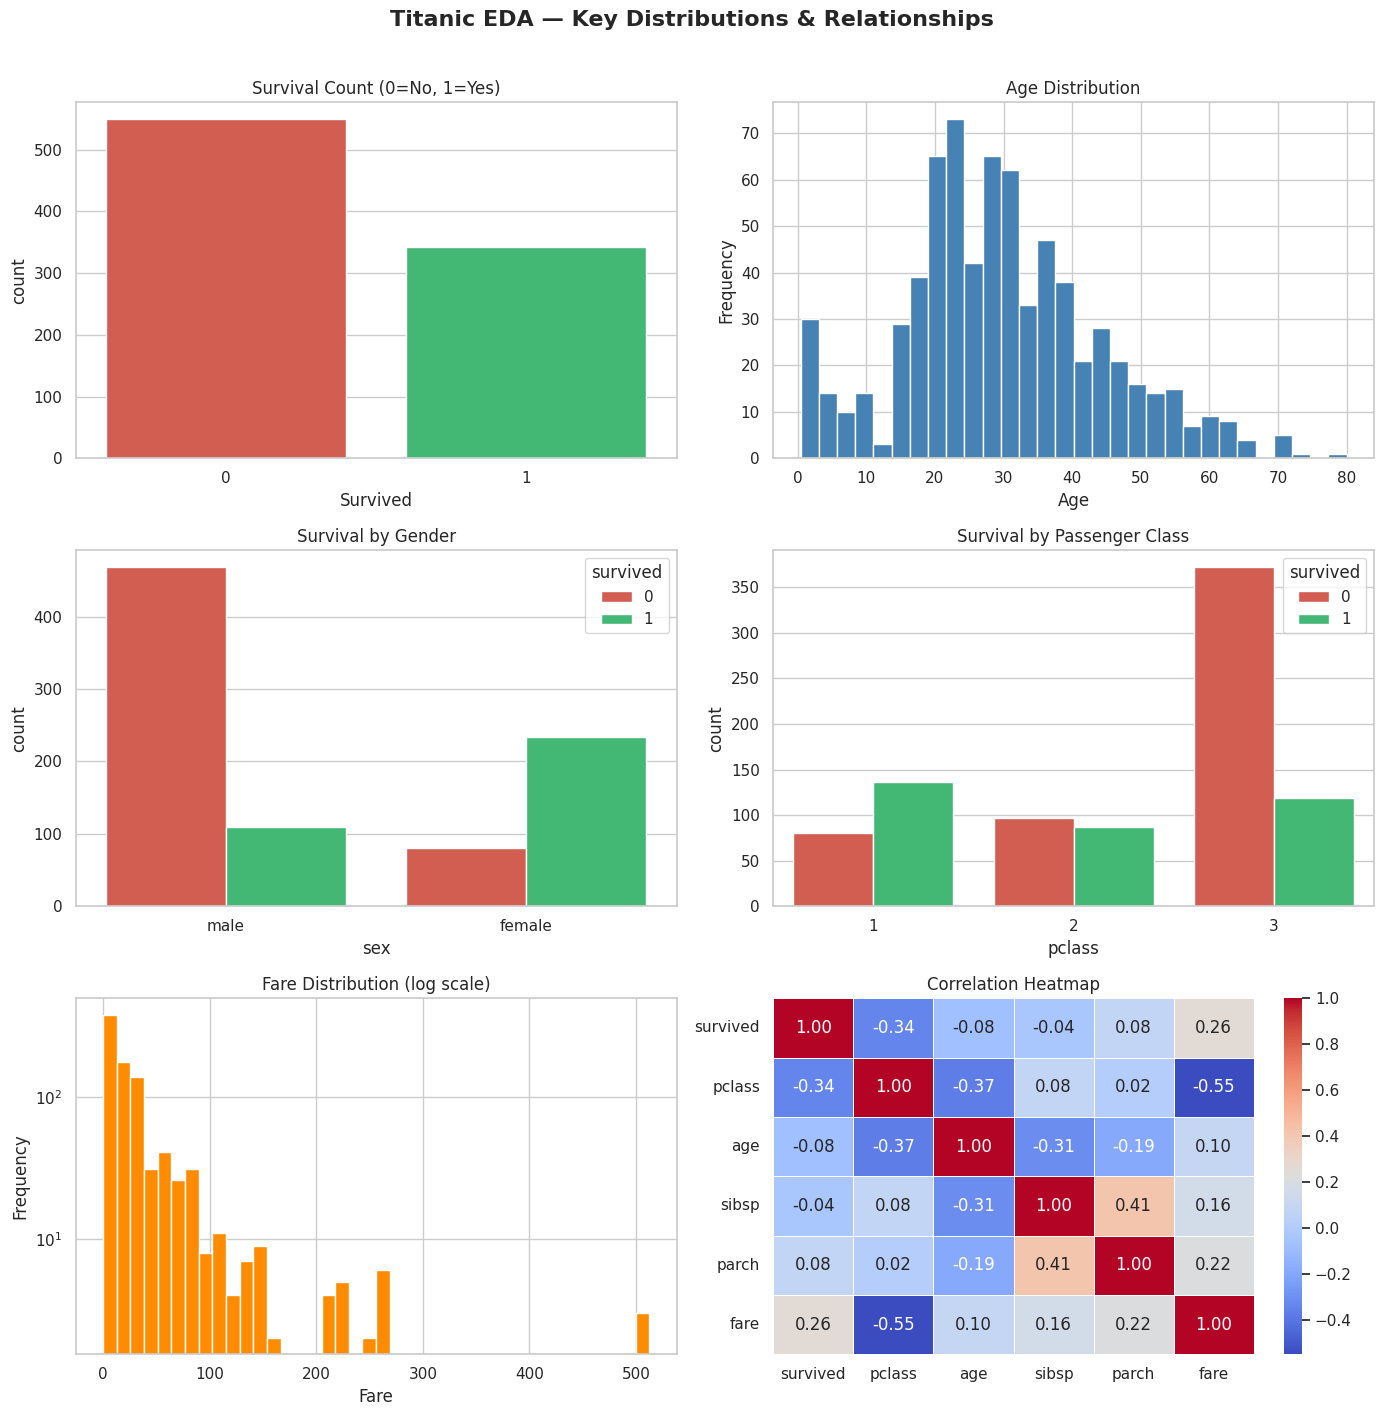


 EDA complete. Plot saved as 'eda_titanic.png'.

 T-Test (Age ~ Survival): t=-2.067, p=0.0391
   → Statistically significant difference in age between groups.

 Key Insights:
   Overall survival rate : 38.4%
   Female survival rate  : 74.2%
   Male survival rate    : 18.9%
   Median age (survived) : 28.0 yrs
   Median age (not surv.): 28.0 yrs


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load Dataset
df = sns.load_dataset('titanic')
print("=" * 55)
print("TITANIC DATASET — EXPLORATORY DATA ANALYSIS")
print("=" * 55)

# 2. Basic Structure
print("\n Shape:", df.shape)
print("\n Data Types:\n", df.dtypes)
print("\n First 5 Rows:\n", df.head())

# 3. Summary Statistics
print("\n Descriptive Statistics (Numeric):\n", df.describe())
print("\n Descriptive Statistics (Categorical):\n",
      df.describe(include='object'))

# 4. Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing,
                           'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print("\n Missing Values:\n", missing_df)

# 5. Visualisations
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle("Titanic EDA — Key Distributions & Relationships",
             fontsize=16, fontweight='bold', y=1.01)

# 5a. Survival Count
sns.countplot(data=df, x='survived', ax=axes[0, 0],
              palette=['#e74c3c', '#2ecc71'])
axes[0, 0].set_title("Survival Count (0=No, 1=Yes)")
axes[0, 0].set_xlabel("Survived")

# 5b. Age Distribution
df['age'].dropna().plot(kind='hist', bins=30, ax=axes[0, 1],
                        color='steelblue', edgecolor='white')
axes[0, 1].set_title("Age Distribution")
axes[0, 1].set_xlabel("Age")

# 5c. Survival by Gender
sns.countplot(data=df, x='sex', hue='survived', ax=axes[1, 0],
              palette=['#e74c3c', '#2ecc71'])
axes[1, 0].set_title("Survival by Gender")

# 5d. Survival by Passenger Class
sns.countplot(data=df, x='pclass', hue='survived', ax=axes[1, 1],
              palette=['#e74c3c', '#2ecc71'])
axes[1, 1].set_title("Survival by Passenger Class")

# 5e. Fare Distribution (log-scaled for clarity)
df['fare'].dropna().plot(kind='hist', bins=40, ax=axes[2, 0],
                         color='darkorange', edgecolor='white',
                         log=True)
axes[2, 0].set_title("Fare Distribution (log scale)")
axes[2, 0].set_xlabel("Fare")

# 5f. Correlation Heatmap
numeric_cols = df.select_dtypes(include=np.number).drop(
    columns=['adult_male'], errors='ignore')
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            ax=axes[2, 1], linewidths=0.5)
axes[2, 1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("eda_titanic.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n EDA complete. Plot saved as 'eda_titanic.png'.")

# 6. Hypothesis Test: Age vs Survival
survived_age = df[df['survived'] == 1]['age'].dropna()
not_survived_age = df[df['survived'] == 0]['age'].dropna()
t_stat, p_value = stats.ttest_ind(survived_age, not_survived_age)
print(f"\n T-Test (Age ~ Survival): t={t_stat:.3f}, p={p_value:.4f}")
if p_value < 0.05:
    print("   → Statistically significant difference in age between groups.")
else:
    print("   → No significant difference in age between groups.")

# 7. Key Insights
survival_rate = df['survived'].mean() * 100
female_survival = df[df['sex'] == 'female']['survived'].mean() * 100
male_survival = df[df['sex'] == 'male']['survived'].mean() * 100
print(f"\n Key Insights:")
print(f"   Overall survival rate : {survival_rate:.1f}%")
print(f"   Female survival rate  : {female_survival:.1f}%")
print(f"   Male survival rate    : {male_survival:.1f}%")
print(f"   Median age (survived) : {survived_age.median():.1f} yrs")
print(f"   Median age (not surv.): {not_survived_age.median():.1f} yrs")